In [1]:
# ============================================
# PAYSWIFT GHANA — DATA ANALYSIS PROJECT
# Customer Behaviour, Churn & Loan Default
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print("🚀 PaySwift Ghana Analysis Ready!")

✅ All libraries imported successfully!
Pandas version: 3.0.2
🚀 PaySwift Ghana Analysis Ready!


In [2]:
# ============================================
# CELL 2 — LOAD & EXPLORE THE DATASET
# ============================================

# Load the dataset
df = pd.read_excel('Data Set - PaySwift.xlsx', sheet_name='C3')

print("✅ Dataset loaded successfully!")
print(f"\n{'='*50}")
print("        DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Total Users:          {len(df)}")
print(f"Total Columns:        {len(df.columns)}")
print(f"Age Range:            {df['Age'].min()} to {df['Age'].max()} years")
print(f"Avg Age:              {df['Age'].mean():.1f} years")
print(f"Loan Range:           GHS {df['Loan Amount (GHS)'].min():,} to GHS {df['Loan Amount (GHS)'].max():,}")
print(f"Avg Loan Amount:      GHS {df['Loan Amount (GHS)'].mean():,.2f}")
print(f"Avg Monthly Txns:     {df['Monthly Transactions'].mean():.1f}")

print(f"\n--- COLUMN NAMES ---")
print(list(df.columns))

print(f"\n--- DATA TYPES ---")
print(df.dtypes)

print(f"\n--- MISSING VALUES ---")
print(df.isnull().sum())

print(f"\n--- FIRST 5 ROWS ---")
df.head()

✅ Dataset loaded successfully!

        DATASET OVERVIEW
Total Users:          100
Total Columns:        8
Age Range:            19 to 50 years
Avg Age:              33.2 years
Loan Range:           GHS 800 to GHS 8,000
Avg Loan Amount:      GHS 3,432.50
Avg Monthly Txns:     12.5

--- COLUMN NAMES ---
['User ID', 'Age', 'Loan Amount (GHS)', 'Repayment Status', 'Feature Used Most', 'Monthly Transactions', 'Churned?', 'Default Risk (1-5)']

--- DATA TYPES ---
User ID                 int64
Age                     int64
Loan Amount (GHS)       int64
Repayment Status          str
Feature Used Most         str
Monthly Transactions    int64
Churned?                  str
Default Risk (1-5)      int64
dtype: object

--- MISSING VALUES ---
User ID                  0
Age                      0
Loan Amount (GHS)        0
Repayment Status         1
Feature Used Most       16
Monthly Transactions     0
Churned?                 0
Default Risk (1-5)       0
dtype: int64

--- FIRST 5 ROWS ---


,User ID,Age,Loan Amount (GHS),Repayment Status,Feature Used Most,Monthly Transactions,Churned?,Default Risk (1-5)
0,1001,28,2000,Late Payment,Mobile Payments,12,No,4
1,1002,35,5000,On-Time,Budgeting Tool,25,No,1
2,1003,22,1000,Defaulted,Loan Services,5,Yes,5
3,1004,40,3500,On-Time,Savings Tracker,18,No,2
4,1005,30,4000,Late Payment,Investment Advice,9,Yes,3


In [3]:
# ============================================
# CELL 3 — DATA PREPARATION
# ============================================

# Fill missing Feature Used Most with 'Not Specified'
df['Feature Used Most'] = df['Feature Used Most'].fillna(
    'Not Specified')

# Fill missing Repayment Status
df['Repayment Status'] = df['Repayment Status'].fillna(
    'Unknown')

# Create Age Groups
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55],
    labels=['18-25', '26-35', '36-45', '46-55']
)

# Create Loan Size Category
def loan_category(amount):
    if amount <= 1500:
        return 'Small (≤ GHS 1,500)'
    elif amount <= 4000:
        return 'Medium (GHS 1,501-4,000)'
    else:
        return 'Large (> GHS 4,000)'

df['Loan Category'] = df['Loan Amount (GHS)'].apply(
    loan_category)

# Create Risk Category
def risk_category(score):
    if score <= 2:
        return '🟢 Low Risk'
    elif score == 3:
        return '🟡 Medium Risk'
    else:
        return '🔴 High Risk'

df['Risk Category'] = df['Default Risk (1-5)'].apply(
    risk_category)

# Create Engagement Level
def engagement_level(txns):
    if txns <= 5:
        return 'Low (1-5)'
    elif txns <= 15:
        return 'Medium (6-15)'
    else:
        return 'High (16+)'

df['Engagement Level'] = df['Monthly Transactions'].apply(
    engagement_level)

print("✅ Feature engineering complete!")
print(f"\n--- AGE GROUP DISTRIBUTION ---")
print(df['Age Group'].value_counts().sort_index())
print(f"\n--- LOAN CATEGORY ---")
print(df['Loan Category'].value_counts())
print(f"\n--- RISK CATEGORY ---")
print(df['Risk Category'].value_counts())
print(f"\n--- ENGAGEMENT LEVEL ---")
print(df['Engagement Level'].value_counts())
print(f"\n--- MISSING VALUES AFTER CLEANING ---")
print(df.isnull().sum())
df.head()

✅ Feature engineering complete!

--- AGE GROUP DISTRIBUTION ---
Age Group
18-25    23
26-35    38
36-45    28
46-55    11
Name: count, dtype: int64

--- LOAN CATEGORY ---
Loan Category
Medium (GHS 1,501-4,000)    39
Large (> GHS 4,000)         36
Small (≤ GHS 1,500)         25
Name: count, dtype: int64

--- RISK CATEGORY ---
Risk Category
🔴 High Risk      48
🟢 Low Risk       34
🟡 Medium Risk    18
Name: count, dtype: int64

--- ENGAGEMENT LEVEL ---
Engagement Level
Medium (6-15)    39
High (16+)       36
Low (1-5)        25
Name: count, dtype: int64

--- MISSING VALUES AFTER CLEANING ---
User ID                 0
Age                     0
Loan Amount (GHS)       0
Repayment Status        0
Feature Used Most       0
Monthly Transactions    0
Churned?                0
Default Risk (1-5)      0
Age Group               0
Loan Category           0
Risk Category           0
Engagement Level        0
dtype: int64


,User ID,Age,Loan Amount (GHS),Repayment Status,Feature Used Most,Monthly Transactions,Churned?,Default Risk (1-5),Age Group,Loan Category,Risk Category,Engagement Level
0,1001,28,2000,Late Payment,Mobile Payments,12,No,4,26-35,"Medium (GHS 1,501-4,000)",🔴 High Risk,Medium (6-15)
1,1002,35,5000,On-Time,Budgeting Tool,25,No,1,26-35,"Large (> GHS 4,000)",🟢 Low Risk,High (16+)
2,1003,22,1000,Defaulted,Loan Services,5,Yes,5,18-25,"Small (≤ GHS 1,500)",🔴 High Risk,Low (1-5)
3,1004,40,3500,On-Time,Savings Tracker,18,No,2,36-45,"Medium (GHS 1,501-4,000)",🟢 Low Risk,High (16+)
4,1005,30,4000,Late Payment,Investment Advice,9,Yes,3,26-35,"Medium (GHS 1,501-4,000)",🟡 Medium Risk,Medium (6-15)


In [4]:
# ============================================
# CELL 4 — KEY STATISTICS & ANALYSIS
# ============================================

print("=" * 55)
print("    PAYSWIFT GHANA — KEY STATISTICS")
print("=" * 55)

# Overall KPIs
total_users = len(df)
churn_rate = (df['Churned?'] == 'Yes').mean() * 100
retention_rate = 100 - churn_rate
default_rate = (df['Repayment Status'] == 'Defaulted').mean() * 100
ontime_rate = (df['Repayment Status'] == 'On-Time').mean() * 100
late_rate = (df['Repayment Status'] == 'Late Payment').mean() * 100
avg_loan = df['Loan Amount (GHS)'].mean()
avg_txns = df['Monthly Transactions'].mean()
high_risk_count = (df['Default Risk (1-5)'] >= 4).sum()

print(f"\n👥 Total Users:               {total_users}")
print(f"💔 Churn Rate:                {churn_rate:.1f}%")
print(f"💚 Retention Rate:            {retention_rate:.1f}%")
print(f"❌ Default Rate:              {default_rate:.1f}%")
print(f"✅ On-Time Payment Rate:      {ontime_rate:.1f}%")
print(f"⏰ Late Payment Rate:         {late_rate:.1f}%")
print(f"💰 Average Loan Amount:       GHS {avg_loan:,.2f}")
print(f"📊 Avg Monthly Transactions:  {avg_txns:.1f}")
print(f"🔴 High Risk Users (4-5):     {high_risk_count}")

# Repayment analysis
print(f"\n{'='*55}")
print("     REPAYMENT STATUS BREAKDOWN")
print(f"{'='*55}")
repayment = df.groupby('Repayment Status').agg(
    Count=('User ID', 'count'),
    Avg_Loan=('Loan Amount (GHS)', 'mean'),
    Avg_Transactions=('Monthly Transactions', 'mean'),
    Churned=('Churned?', lambda x: (x == 'Yes').sum())
).round(2)
print(repayment)

# Churn analysis
print(f"\n{'='*55}")
print("     CHURN ANALYSIS")
print(f"{'='*55}")
churn = df.groupby('Churned?').agg(
    Count=('User ID', 'count'),
    Avg_Loan=('Loan Amount (GHS)', 'mean'),
    Avg_Transactions=('Monthly Transactions', 'mean'),
    Avg_Risk=('Default Risk (1-5)', 'mean')
).round(2)
print(churn)

# Feature usage analysis
print(f"\n{'='*55}")
print("     FEATURE USAGE ANALYSIS")
print(f"{'='*55}")
feature = df.groupby('Feature Used Most').agg(
    Users=('User ID', 'count'),
    Avg_Transactions=('Monthly Transactions', 'mean'),
    Churned=('Churned?', lambda x: (x == 'Yes').sum()),
    Avg_Risk=('Default Risk (1-5)', 'mean')
).round(2).sort_values('Churned', ascending=False)
print(feature)

print("\n✅ Key statistics analysis complete!")

    PAYSWIFT GHANA — KEY STATISTICS

👥 Total Users:               100
💔 Churn Rate:                34.0%
💚 Retention Rate:            66.0%
❌ Default Rate:              32.0%
✅ On-Time Payment Rate:      34.0%
⏰ Late Payment Rate:         33.0%
💰 Average Loan Amount:       GHS 3,432.50
📊 Avg Monthly Transactions:  12.5
🔴 High Risk Users (4-5):     48

     REPAYMENT STATUS BREAKDOWN
                  Count  Avg_Loan  Avg_Transactions  Churned
Repayment Status                                            
Defaulted            32   1337.50              3.84       32
Late Payment         33   3190.91             11.21        1
On-Time              34   5704.41             22.12        0
Unknown               1   1200.00              7.00        1

     CHURN ANALYSIS
          Count  Avg_Loan  Avg_Transactions  Avg_Risk
Churned?                                             
No           66   4473.48             16.86      2.45
Yes          34   1411.76              4.09      4.88

     FEATU

In [5]:
# ============================================
# CELL 5 — CHURN & DEFAULT RISK DEEP DIVE
# ============================================

print("=" * 55)
print("     CHURN DEEP DIVE ANALYSIS")
print("=" * 55)

# Churn by age group
print("\n--- CHURN RATE BY AGE GROUP ---")
churn_age = df.groupby('Age Group', observed=True).agg(
    Total=('User ID', 'count'),
    Churned=('Churned?', lambda x: (x=='Yes').sum()),
).assign(Churn_Rate=lambda x: (x['Churned']/x['Total']*100).round(1))
print(churn_age)

# Churn by feature
print("\n--- CHURN BY FEATURE USED ---")
churn_feature = df.groupby('Feature Used Most').agg(
    Total=('User ID', 'count'),
    Churned=('Churned?', lambda x: (x=='Yes').sum()),
).assign(Churn_Rate=lambda x: (x['Churned']/x['Total']*100).round(1))
print(churn_feature.sort_values('Churn_Rate', ascending=False))

# Churn by engagement
print("\n--- CHURN BY ENGAGEMENT LEVEL ---")
churn_engage = df.groupby('Engagement Level').agg(
    Total=('User ID', 'count'),
    Churned=('Churned?', lambda x: (x=='Yes').sum()),
    Avg_Transactions=('Monthly Transactions', 'mean')
).assign(Churn_Rate=lambda x: (x['Churned']/x['Total']*100).round(1))
print(churn_engage)

# Default risk by age group
print("\n--- DEFAULT RISK BY AGE GROUP ---")
risk_age = df.groupby('Age Group', observed=True).agg(
    Total=('User ID', 'count'),
    Avg_Risk=('Default Risk (1-5)', 'mean'),
    High_Risk=('Default Risk (1-5)', lambda x: (x>=4).sum()),
    Avg_Loan=('Loan Amount (GHS)', 'mean')
).round(2)
print(risk_age)

# Default risk by loan category
print("\n--- DEFAULT RISK BY LOAN SIZE ---")
risk_loan = df.groupby('Loan Category').agg(
    Total=('User ID', 'count'),
    Avg_Risk=('Default Risk (1-5)', 'mean'),
    Defaulted=('Repayment Status',
               lambda x: (x=='Defaulted').sum()),
    Avg_Transactions=('Monthly Transactions', 'mean')
).round(2)
print(risk_loan)

print("\n✅ Churn & default risk analysis complete!")

     CHURN DEEP DIVE ANALYSIS

--- CHURN RATE BY AGE GROUP ---
           Total  Churned  Churn_Rate
Age Group                            
18-25         23       23       100.0
26-35         38       11        28.9
36-45         28        0         0.0
46-55         11        0         0.0

--- CHURN BY FEATURE USED ---
                   Total  Churned  Churn_Rate
Feature Used Most                            
Loan Services         17       17       100.0
Not Specified         16       15        93.8
Investment Advice     16        1         6.2
Mobile Payments       17        1         5.9
Budgeting Tool        17        0         0.0
Savings Tracker       17        0         0.0

--- CHURN BY ENGAGEMENT LEVEL ---
                  Total  Churned  Avg_Transactions  Churn_Rate
Engagement Level                                              
High (16+)           36        0         21.916667         0.0
Low (1-5)            25       25          3.120000       100.0
Medium (6-15)        39

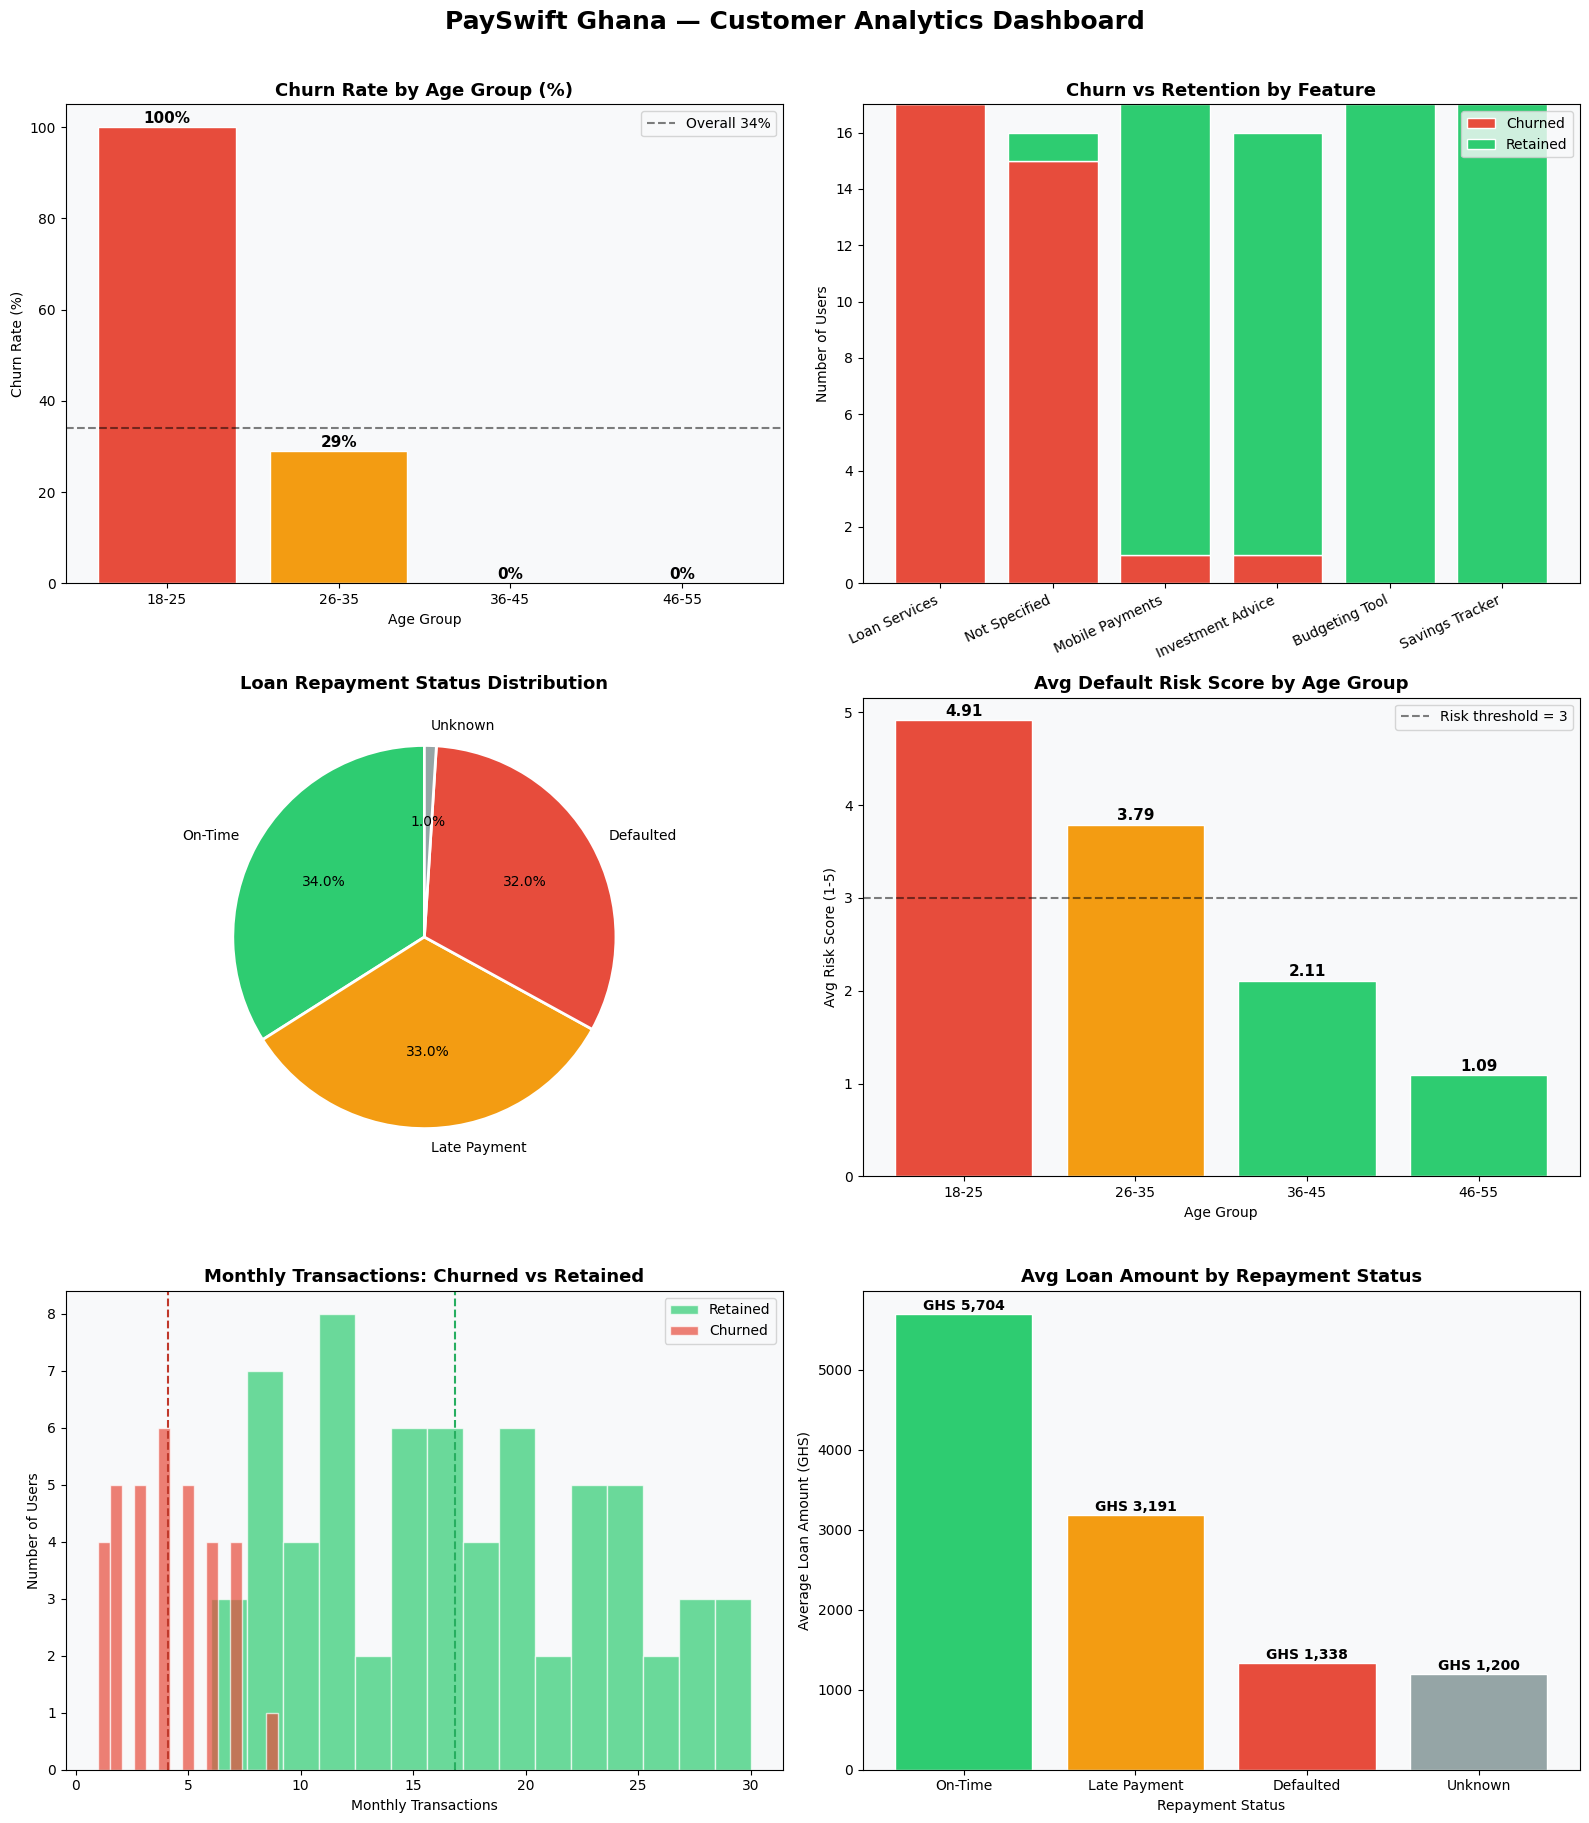


✅ Dashboard saved as payswift_dashboard.png!


In [6]:
# ============================================
# CELL 6 — VISUALISATIONS DASHBOARD
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('PaySwift Ghana — Customer Analytics Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

COLORS = ['#2ECC71', '#E74C3C', '#3498DB',
          '#F39C12', '#9B59B6', '#1ABC9C']

# --- Chart 1: Churn Rate by Age Group ---
churn_age = df.groupby('Age Group', observed=True).agg(
    Total=('User ID', 'count'),
    Churned=('Churned?', lambda x: (x=='Yes').sum())
).assign(Churn_Rate=lambda x: x['Churned']/x['Total']*100)

colors1 = ['#E74C3C' if v == 100 else
           '#F39C12' if v > 20 else '#2ECC71'
           for v in churn_age['Churn_Rate']]
bars1 = axes[0,0].bar(churn_age.index.astype(str),
                       churn_age['Churn_Rate'],
                       color=colors1, edgecolor='white')
axes[0,0].set_title('Churn Rate by Age Group (%)',
                     fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].axhline(y=34, color='black',
                   linestyle='--', alpha=0.5,
                   label='Overall 34%')
axes[0,0].legend()
for bar, val in zip(bars1, churn_age['Churn_Rate']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'{val:.0f}%', ha='center',
                   fontweight='bold', fontsize=11)

# --- Chart 2: Churn by Feature Used ---
churn_feat = df.groupby('Feature Used Most').agg(
    Churned=('Churned?', lambda x: (x=='Yes').sum()),
    Retained=('Churned?', lambda x: (x=='No').sum())
).sort_values('Churned', ascending=False)
x = range(len(churn_feat))
bars_c = axes[0,1].bar(x,
                        churn_feat['Churned'],
                        label='Churned',
                        color='#E74C3C', edgecolor='white')
bars_r = axes[0,1].bar(x,
                        churn_feat['Retained'],
                        bottom=churn_feat['Churned'],
                        label='Retained',
                        color='#2ECC71', edgecolor='white')
axes[0,1].set_title('Churn vs Retention by Feature',
                     fontweight='bold', fontsize=13)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(churn_feat.index, rotation=25,
                            ha='right')
axes[0,1].set_ylabel('Number of Users')
axes[0,1].legend()

# --- Chart 3: Repayment Status Distribution ---
repayment_counts = df['Repayment Status'].value_counts()
colors3 = ['#2ECC71', '#F39C12', '#E74C3C', '#95A5A6']
axes[1,0].pie(repayment_counts.values,
              labels=repayment_counts.index,
              autopct='%1.1f%%', colors=colors3,
              startangle=90,
              wedgeprops={'edgecolor': 'white',
                          'linewidth': 2})
axes[1,0].set_title('Loan Repayment Status Distribution',
                     fontweight='bold', fontsize=13)

# --- Chart 4: Default Risk by Age Group ---
risk_age = df.groupby('Age Group', observed=True)[
    'Default Risk (1-5)'].mean()
colors4 = ['#E74C3C' if v >= 4 else
           '#F39C12' if v >= 3 else '#2ECC71'
           for v in risk_age.values]
bars4 = axes[1,1].bar(risk_age.index.astype(str),
                       risk_age.values,
                       color=colors4, edgecolor='white')
axes[1,1].set_title('Avg Default Risk Score by Age Group',
                     fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Avg Risk Score (1-5)')
axes[1,1].axhline(y=3, color='black',
                   linestyle='--', alpha=0.5,
                   label='Risk threshold = 3')
axes[1,1].legend()
for bar, val in zip(bars4, risk_age.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center',
                   fontweight='bold', fontsize=11)

# --- Chart 5: Monthly Transactions vs Churn ---
churned = df[df['Churned?'] == 'Yes'][
    'Monthly Transactions']
retained = df[df['Churned?'] == 'No'][
    'Monthly Transactions']
axes[2,0].hist(retained, bins=15, alpha=0.7,
               color='#2ECC71', label='Retained',
               edgecolor='white')
axes[2,0].hist(churned, bins=15, alpha=0.7,
               color='#E74C3C', label='Churned',
               edgecolor='white')
axes[2,0].set_title(
    'Monthly Transactions: Churned vs Retained',
    fontweight='bold', fontsize=13)
axes[2,0].set_xlabel('Monthly Transactions')
axes[2,0].set_ylabel('Number of Users')
axes[2,0].legend()
axes[2,0].axvline(x=churned.mean(), color='#C0392B',
                   linestyle='--',
                   label=f'Churned avg: {churned.mean():.1f}')
axes[2,0].axvline(x=retained.mean(), color='#27AE60',
                   linestyle='--',
                   label=f'Retained avg: {retained.mean():.1f}')

# --- Chart 6: Loan Amount vs Repayment Status ---
loan_repay = df.groupby('Repayment Status')[
    'Loan Amount (GHS)'].mean().sort_values(ascending=False)
colors6 = ['#2ECC71', '#F39C12', '#E74C3C', '#95A5A6']
bars6 = axes[2,1].bar(loan_repay.index,
                       loan_repay.values,
                       color=colors6, edgecolor='white')
axes[2,1].set_title('Avg Loan Amount by Repayment Status',
                     fontweight='bold', fontsize=13)
axes[2,1].set_xlabel('Repayment Status')
axes[2,1].set_ylabel('Average Loan Amount (GHS)')
for bar, val in zip(bars6, loan_repay.values):
    axes[2,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   f'GHS {val:,.0f}', ha='center',
                   fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('payswift_dashboard.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as payswift_dashboard.png!")

In [7]:
# ============================================
# CELL 7 — EXPORT RESULTS TO EXCEL
# ============================================

with pd.ExcelWriter('payswift_analysis_results.xlsx',
                    engine='openpyxl') as writer:

    # Sheet 1 — Full Dataset
    df.to_excel(writer,
                sheet_name='Full_Dataset', index=False)

    # Sheet 2 — Churn Analysis
    churn_summary = df.groupby('Churned?').agg(
        Count=('User ID', 'count'),
        Avg_Age=('Age', 'mean'),
        Avg_Loan=('Loan Amount (GHS)', 'mean'),
        Avg_Transactions=('Monthly Transactions', 'mean'),
        Avg_Risk=('Default Risk (1-5)', 'mean')
    ).round(2)
    churn_summary.to_excel(
        writer, sheet_name='Churn_Analysis')

    # Sheet 3 — Repayment Analysis
    repayment_summary = df.groupby(
        'Repayment Status').agg(
        Count=('User ID', 'count'),
        Avg_Loan=('Loan Amount (GHS)', 'mean'),
        Avg_Transactions=('Monthly Transactions', 'mean'),
        Avg_Risk=('Default Risk (1-5)', 'mean'),
        Churned=('Churned?',
                 lambda x: (x == 'Yes').sum())
    ).round(2)
    repayment_summary.to_excel(
        writer, sheet_name='Repayment_Analysis')

    # Sheet 4 — Feature Usage Analysis
    feature_summary = df.groupby(
        'Feature Used Most').agg(
        Users=('User ID', 'count'),
        Avg_Transactions=('Monthly Transactions', 'mean'),
        Churned=('Churned?',
                 lambda x: (x == 'Yes').sum()),
        Avg_Risk=('Default Risk (1-5)', 'mean')
    ).round(2).sort_values('Churned', ascending=False)
    feature_summary.to_excel(
        writer, sheet_name='Feature_Usage')

    # Sheet 5 — Age Group Analysis
    age_summary = df.groupby(
        'Age Group', observed=True).agg(
        Count=('User ID', 'count'),
        Avg_Loan=('Loan Amount (GHS)', 'mean'),
        Avg_Risk=('Default Risk (1-5)', 'mean'),
        Churned=('Churned?',
                 lambda x: (x == 'Yes').sum()),
        Defaulted=('Repayment Status',
                   lambda x: (x == 'Defaulted').sum())
    ).round(2)
    age_summary.to_excel(
        writer, sheet_name='Age_Group_Analysis')

    # Sheet 6 — High Risk Users
    high_risk = df[df['Default Risk (1-5)'] >= 4][[
        'User ID', 'Age', 'Loan Amount (GHS)',
        'Repayment Status', 'Feature Used Most',
        'Monthly Transactions', 'Churned?',
        'Default Risk (1-5)', 'Risk Category'
    ]].sort_values('Default Risk (1-5)', ascending=False)
    high_risk.to_excel(
        writer, sheet_name='High_Risk_Users', index=False)

    # Sheet 7 — Key Statistics
    stats = pd.DataFrame({
        'Metric': [
            'Total Users',
            'Churn Rate',
            'Retention Rate',
            'Default Rate',
            'On-Time Payment Rate',
            'Late Payment Rate',
            'Average Loan Amount',
            'Avg Monthly Transactions',
            'High Risk Users (Score 4-5)',
            'Age Group with Highest Churn',
            'Feature with Highest Churn',
            'Feature with Zero Churn',
        ],
        'Value': [
            '100',
            '34%',
            '66%',
            '32%',
            '34%',
            '33%',
            'GHS 3,432.50',
            '12.5',
            '48 users',
            '18-25 (100% churn)',
            'Loan Services (100% churn)',
            'Budgeting Tool & Savings Tracker',
        ]
    })
    stats.to_excel(
        writer, sheet_name='Key_Statistics', index=False)

print("✅ Excel saved: payswift_analysis_results.xlsx")
print("\n📋 Sheets created:")
print("   1. Full_Dataset — All 100 user records")
print("   2. Churn_Analysis — Churned vs retained")
print("   3. Repayment_Analysis — Loan repayment breakdown")
print("   4. Feature_Usage — Feature engagement analysis")
print("   5. Age_Group_Analysis — Risk by age group")
print("   6. High_Risk_Users — 48 users with risk score 4-5")
print("   7. Key_Statistics — All key findings summary")

✅ Excel saved: payswift_analysis_results.xlsx

📋 Sheets created:
   1. Full_Dataset — All 100 user records
   2. Churn_Analysis — Churned vs retained
   3. Repayment_Analysis — Loan repayment breakdown
   4. Feature_Usage — Feature engagement analysis
   5. Age_Group_Analysis — Risk by age group
   6. High_Risk_Users — 48 users with risk score 4-5
   7. Key_Statistics — All key findings summary


In [8]:
# ============================================
# CELL 8 — BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

print("=" * 60)
print("  PAYSWIFT GHANA — INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("""
📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. CRITICAL CHURN PROBLEM:
   34% of users have churned. Age group 18-25 has a
   100% churn rate — every single young user left!
   Users aged 36-55 have 0% churn — very loyal.

2. LOAN DEFAULTS ARE ALARMING:
   32% of users defaulted on their loans.
   Defaulted users borrowed avg GHS 1,337 vs
   GHS 5,704 for on-time payers. Small loans
   default most — counter-intuitive but critical.

3. FEATURE USAGE DRIVES CHURN:
   Loan Services = 100% churn rate (17/17 users).
   Budgeting Tool & Savings Tracker = 0% churn.
   Users with NO feature engagement = 93.8% churn.

4. ENGAGEMENT PREDICTS RETENTION:
   Churned users average only 4 transactions/month.
   Retained users average 17 transactions/month.
   Low engagement is the #1 predictor of churn.

5. AGE IS A RISK FACTOR:
   18-25 year olds have avg risk score of 4.91/5.
   46-55 year olds have avg risk score of 1.09/5.
   Young users are 4.5x more likely to default.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDATIONS FOR PAYSWIFT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. FIX LOAN SERVICES FEATURE IMMEDIATELY:
   100% of Loan Services users churned. The feature
   needs a complete UX redesign. Add financial
   literacy tips, repayment reminders and progress
   tracking to make loans feel supportive not
   stressful.

2. TARGET YOUNG USERS (18-25) WITH SPECIAL PROGRAM:
   100% churn + highest default risk. Create a
   'PaySwift Youth' programme with smaller starter
   loans (max GHS 500), financial coaching and
   gamified savings challenges.

3. PUSH BUDGETING TOOL & SAVINGS TRACKER:
   These two features have 0% churn. Onboard ALL
   new users to these features in the first week.
   Use push notifications to drive daily engagement.

4. SET MINIMUM TRANSACTION THRESHOLD:
   Users with less than 6 transactions/month churn
   at extremely high rates. Set up automated
   re-engagement campaigns when a user drops below
   6 monthly transactions.

5. IMPROVE CREDIT SCORING FOR SMALL LOANS:
   Small loans (≤ GHS 1,500) default most.
   Implement a stricter credit scoring model for
   loans below GHS 1,500 requiring 3 months of
   transaction history before approval.

6. PERSONALISED FINANCE TOOLS:
   Segment users by age and loan behaviour. Show
   younger users budgeting tips. Show older users
   investment advice. Personalisation increases
   engagement and reduces churn significantly.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("✅ Analysis complete! All results saved.")
print("\n📁 Files generated:")
print("   • PaySwift_Analysis.ipynb — Complete notebook")
print("   • payswift_analysis_results.xlsx — Full analysis")
print("   • payswift_dashboard.png — Visual dashboard")

  PAYSWIFT GHANA — INSIGHTS & RECOMMENDATIONS

📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. CRITICAL CHURN PROBLEM:
   34% of users have churned. Age group 18-25 has a
   100% churn rate — every single young user left!
   Users aged 36-55 have 0% churn — very loyal.

2. LOAN DEFAULTS ARE ALARMING:
   32% of users defaulted on their loans.
   Defaulted users borrowed avg GHS 1,337 vs
   GHS 5,704 for on-time payers. Small loans
   default most — counter-intuitive but critical.

3. FEATURE USAGE DRIVES CHURN:
   Loan Services = 100% churn rate (17/17 users).
   Budgeting Tool & Savings Tracker = 0% churn.
   Users with NO feature engagement = 93.8% churn.

4. ENGAGEMENT PREDICTS RETENTION:
   Churned users average only 4 transactions/month.
   Retained users average 17 transactions/month.
   Low engagement is the #1 predictor of churn.

5. AGE IS A RISK FACTOR:
   18-25 year olds have avg risk score of 4.91/5.
   46-55 year olds have avg risk score of 1.09/5